# 04 — Evaluation & Error Analysis

**Goal:** Load a saved model checkpoint, run predictions on held-out data,
compute quantitative metrics, and visually inspect where the model succeeds and fails.

---

## Why error analysis matters

A single accuracy or mIoU number tells you *how well* a model performs on average,
but not *why* it fails or *which* failure modes are most important to fix.

Common failure modes in Mars terrain segmentation:
- **Sand/soil confusion** — these classes look similar in colour and texture.
- **Missed small rocks** — low-resolution features are hard for shallow models.
- **Shadow regions** — dark areas may be misclassified as bedrock.
- **Boundary bleeding** — class boundaries are smeared, especially at coarse resolution.

> **Prerequisite:** Run `03_baseline_training.ipynb` first to save a checkpoint.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

from src.data_paths import RAW_DATA_DIR, MODELS_DIR, FIGURES_DIR, PREDICTIONS_DIR, ensure_project_dirs
from src.dataset import AI4MarsDataset, find_image_files, find_mask_files, build_pairs_by_stem
from src.train_utils import get_device, load_checkpoint
from src.metrics import pixel_accuracy, intersection_over_union, mean_iou
from src.visualize import CLASS_NAMES, show_image, show_image_mask_overlay

ensure_project_dirs()

All project directories are ready.


## Step 1 — Rebuild the Same Model Architecture

The checkpoint only stores **weights**, not the model class definition.  
You must define the same architecture here before loading.

In [10]:
import segmentation_models_pytorch as smp

NUM_CLASSES = 4
IGNORE_INDEX = 255
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 4
VAL_SPLIT = 0.1

# Baseline weighted-loss setup used during training in notebook 03.
BASE_CLASS_WEIGHTS = torch.tensor([1.0, 2.5, 1.5, 4.0], dtype=torch.float32)

# Toggle to test data-driven class weights from the train split stats below.
USE_DYNAMIC_CLASS_WEIGHTS = True
CLASS_WEIGHTS = BASE_CLASS_WEIGHTS  # backward-compatible alias

device = get_device()

def build_unet(encoder_name: str, num_classes: int, device: torch.device):
    return smp.Unet(
        encoder_name=encoder_name,
        encoder_weights="imagenet",
        in_channels=3,
        classes=num_classes,
    ).to(device)

def infer_encoder_name(state_dict: dict) -> str:
    # Checkpoint from 03 can be either resnet34 (CUDA path) or mobilenet_v2 (CPU path).
    keys = list(state_dict.keys())
    if any(k.startswith("encoder.layer1.") for k in keys):
        return "resnet34"
    if any(k.startswith("encoder.features.") for k in keys):
        return "mobilenet_v2"
    raise RuntimeError("Could not infer encoder type from checkpoint state_dict.")

Using device: cuda


## Step 2 — Load Checkpoint

In [11]:
checkpoint_path = MODELS_DIR / "weighted_unet_epoch03.pth"

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location=device)
    encoder_name = infer_encoder_name(checkpoint["model_state_dict"])

    model = build_unet(encoder_name, NUM_CLASSES, device)
    optimizer = torch.optim.Adam(model.parameters())  # needed by load_checkpoint

    epoch = load_checkpoint(model, optimizer, checkpoint_path, device)
    print(f"Loaded checkpoint from epoch {epoch}")
    print(f"Loaded model architecture: U-Net with encoder='{encoder_name}'")
else:
    raise FileNotFoundError(
        f"Checkpoint not found at {checkpoint_path}. "
        "Run 03_baseline_training.ipynb first."
    )

Checkpoint loaded from C:\Users\Jacob\AI4Mars\models\weighted_unet_epoch03.pth  (epoch 3)
Loaded checkpoint from epoch 3
Loaded model architecture: U-Net with encoder='resnet34'


## Step 3 — Recreate the Validation Set

In [8]:
DATA_ROOT = RAW_DATA_DIR

image_files = find_image_files(DATA_ROOT)
mask_files = find_mask_files(DATA_ROOT)
pairs = build_pairs_by_stem(image_files, mask_files)

# Match notebook 03 exactly: evaluate NAV-only pairs for the 4-class setup.
pairs = [(img, msk) for img, msk in pairs if "M2020_GEO" not in str(msk)]

total = len(pairs)
val_size = max(1, int(total * VAL_SPLIT))
train_size = total - val_size

full_dataset = AI4MarsDataset(pairs, image_size=IMAGE_SIZE)
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),  # same seed as notebook 03
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples (NAV-only): {len(train_dataset)}")
print(f"Validation samples (NAV-only): {len(val_dataset)}")

Train samples (NAV-only): 34163
Validation samples (NAV-only): 3795


## Step 3.5 — Diagnose Class Imbalance and Propose Weights

In [12]:
train_loader_stats = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
class_pixel_counts = torch.zeros(NUM_CLASSES, dtype=torch.long)

for _, masks in train_loader_stats:
    valid = masks != IGNORE_INDEX
    for c in range(NUM_CLASSES):
        class_pixel_counts[c] += ((masks == c) & valid).sum()

total_labeled_pixels = class_pixel_counts.sum().item()
class_freq = class_pixel_counts.float() / max(total_labeled_pixels, 1)
inverse_freq = 1.0 / torch.clamp(class_freq, min=1e-8)
dynamic_class_weights = inverse_freq / inverse_freq.mean()

print("Train-split labeled pixel counts by class:")
for c in range(NUM_CLASSES):
    name = CLASS_NAMES.get(c, f"class_{c}")
    print(
        f"  class {c} ({name:>10s}): {class_pixel_counts[c].item():>12d} pixels "
        f"({class_freq[c].item() * 100:6.2f}%)"
    )

print("\nBaseline class weights (from notebook 03):")
for c in range(NUM_CLASSES):
    name = CLASS_NAMES.get(c, f"class_{c}")
    print(f"  class {c} ({name:>10s}): {BASE_CLASS_WEIGHTS[c].item():.4f}")

print("\nProposed dynamic class weights (inverse-frequency, mean-normalized):")
for c in range(NUM_CLASSES):
    name = CLASS_NAMES.get(c, f"class_{c}")
    print(f"  class {c} ({name:>10s}): {dynamic_class_weights[c].item():.4f}")

ACTIVE_CLASS_WEIGHTS = dynamic_class_weights if USE_DYNAMIC_CLASS_WEIGHTS else BASE_CLASS_WEIGHTS
print(f"\nUsing {'dynamic' if USE_DYNAMIC_CLASS_WEIGHTS else 'baseline'} class weights for loss.")
print(f"Active weights: {ACTIVE_CLASS_WEIGHTS.tolist()}")

Train-split labeled pixel counts by class:
  class 0 (      soil):    574428237 pixels ( 39.61%)
  class 1 (   bedrock):    415157397 pixels ( 28.63%)
  class 2 (      sand):    398192615 pixels ( 27.46%)
  class 3 (  big_rock):     62455789 pixels (  4.31%)

Baseline class weights (from notebook 03):
  class 0 (      soil): 1.0000
  class 1 (   bedrock): 2.5000
  class 2 (      sand): 1.5000
  class 3 (  big_rock): 4.0000

Proposed dynamic class weights (inverse-frequency, mean-normalized):
  class 0 (      soil): 0.3071
  class 1 (   bedrock): 0.4250
  class 2 (      sand): 0.4431
  class 3 (  big_rock): 2.8248

Using dynamic class weights for loss.
Active weights: [0.30713504552841187, 0.42496421933174133, 0.44306960701942444, 2.824831008911133]


## Step 4 — Run Predictions and Compute Metrics

In [ ]:
# Safety first: free any cached CUDA memory from prior runs.
if torch.cuda.is_available():
    torch.cuda.empty_cache()

weights_for_loss = ACTIVE_CLASS_WEIGHTS if 'ACTIVE_CLASS_WEIGHTS' in globals() else BASE_CLASS_WEIGHTS
loss_fn = nn.CrossEntropyLoss(weight=weights_for_loss.to(device), ignore_index=IGNORE_INDEX)
print(f"Loss weights in use: {weights_for_loss.tolist()}")

# 1) Smoke-test one batch to validate memory behavior before full eval.
model.eval()
with torch.no_grad():
    images, masks = next(iter(val_loader))
    images = images.to(device)
    outputs = model(images)

    # Move results back to CPU before further analysis/visualization.
    preds = outputs.argmax(dim=1).cpu()
    images = images.cpu()
    masks = masks.cpu()

print(f"Smoke test batch ok: images={tuple(images.shape)}, preds={tuple(preds.shape)}")

# 2) Optional full validation pass. Keep False while debugging OOM.
RUN_FULL_EVAL = True

if RUN_FULL_EVAL:
    all_preds = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)  # [B, num_classes, H, W]
            loss = loss_fn(logits, masks)
            total_loss += loss.item()

            # argmax converts logits -> predicted class ID per pixel
            pred_batch = logits.argmax(dim=1)  # [B, H, W]
            all_preds.append(pred_batch.cpu())
            all_targets.append(masks.cpu())

    all_preds = torch.cat(all_preds, dim=0)      # [N, H, W]
    all_targets = torch.cat(all_targets, dim=0)  # [N, H, W]

    sample_mious = []
    for sample_idx in range(all_preds.shape[0]):
        sample_iou = intersection_over_union(
            all_preds[sample_idx:sample_idx + 1],
            all_targets[sample_idx:sample_idx + 1],
            num_classes=NUM_CLASSES,
            ignore_index=IGNORE_INDEX,
        )
        valid_scores = [iou for iou in sample_iou if iou is not None]
        sample_mious.append(sum(valid_scores) / len(valid_scores) if valid_scores else 0.0)

    ranked_samples = sorted(range(len(sample_mious)), key=lambda idx: sample_mious[idx], reverse=True)
    best_sample_ids = ranked_samples[:3]
    worst_sample_ids = list(reversed(ranked_samples[-3:]))

    mean_val_loss = total_loss / len(val_loader)
    pix_acc = pixel_accuracy(all_preds, all_targets, ignore_index=IGNORE_INDEX)
    per_class_iou = intersection_over_union(
        all_preds,
        all_targets,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )
    m_iou = mean_iou(
        all_preds,
        all_targets,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    print(f"Validation loss (weighted): {mean_val_loss:.4f}")
    print(f"Pixel accuracy            : {pix_acc:.4f}")
    print(f"Mean IoU                  : {m_iou:.4f}")
    print("\nPer-class IoU:")
    for c, iou in enumerate(per_class_iou):
        name = CLASS_NAMES.get(c, f"class_{c}")
        iou_str = f"{iou:.4f}" if iou is not None else "N/A (not in batch)"
        print(f"  class {c} ({name:>10s}): {iou_str}")

    print("\nBest validation samples by mean IoU:")
    for sample_id in best_sample_ids:
        print(f"  sample {sample_id + 1:>4d}: mIoU={sample_mious[sample_id]:.4f}")

    print("\nWorst validation samples by mean IoU:")
    for sample_id in worst_sample_ids:
        print(f"  sample {sample_id + 1:>4d}: mIoU={sample_mious[sample_id]:.4f}")
else:
    print("Skipped full evaluation (RUN_FULL_EVAL=False). Set True after smoke test passes.")

Loss weights in use: [0.30713504552841187, 0.42496421933174133, 0.44306960701942444, 2.824831008911133]
Smoke test batch ok: images=(4, 3, 256, 256), preds=(4, 256, 256)
Validation loss (weighted): 0.7372
Pixel accuracy            : 0.7477
Mean IoU                  : 0.5364

Per-class IoU:
  class 0 (      soil): 0.5905
  class 1 (   bedrock): 0.6964
  class 2 (      sand): 0.5810
  class 3 (  big_rock): 0.2776


## Step 5 — Visual Prediction Comparison

Show the best and worst validation examples, and save overlay figures for later review.

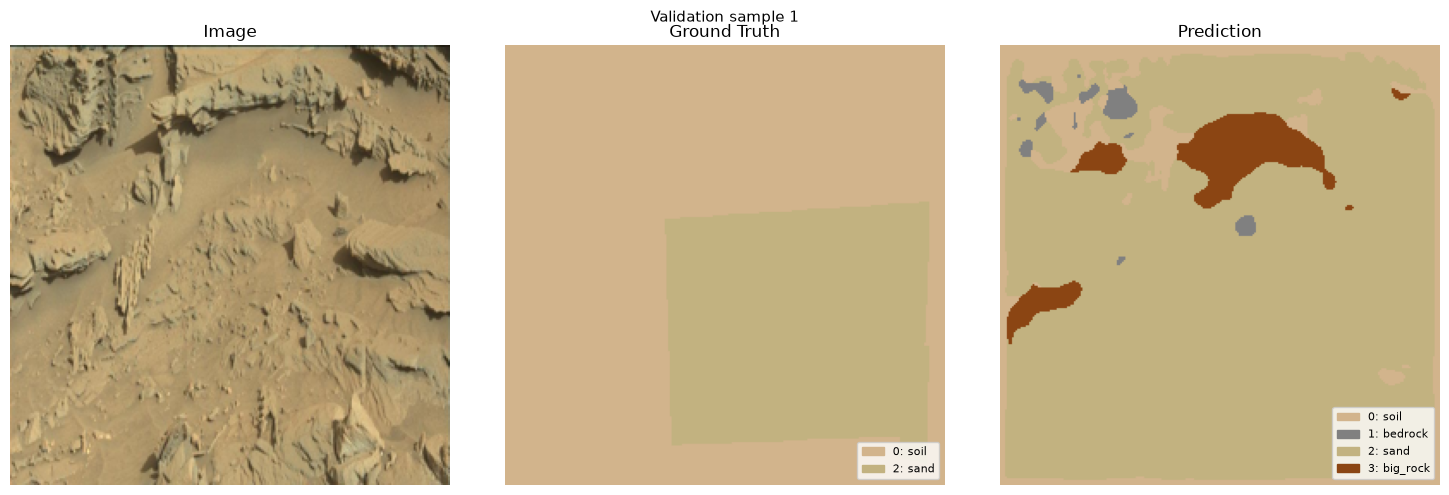

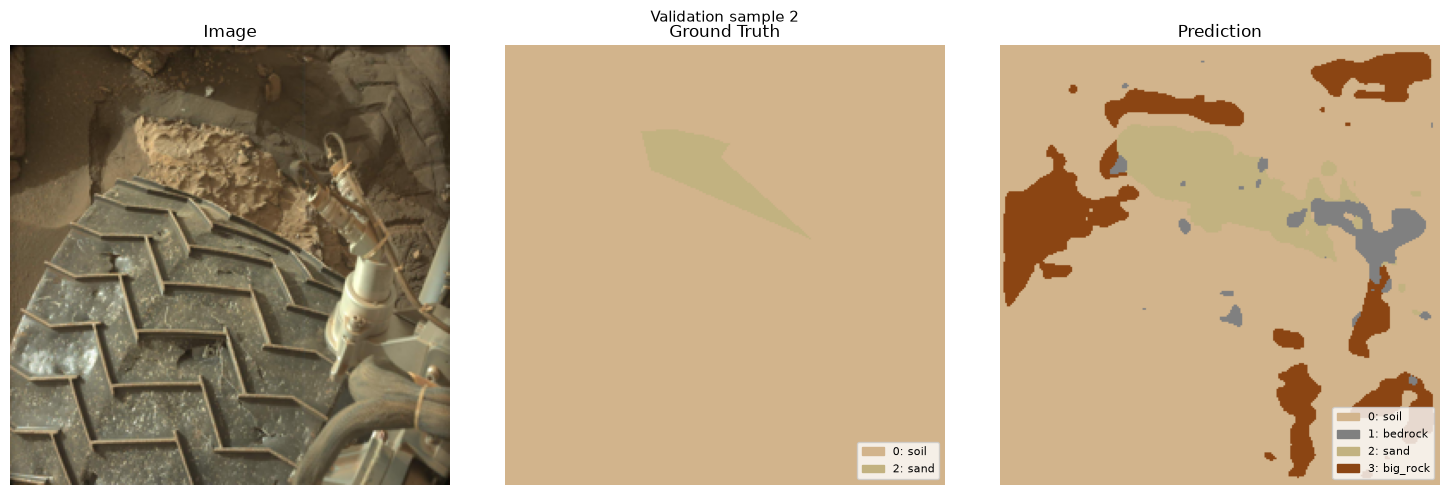

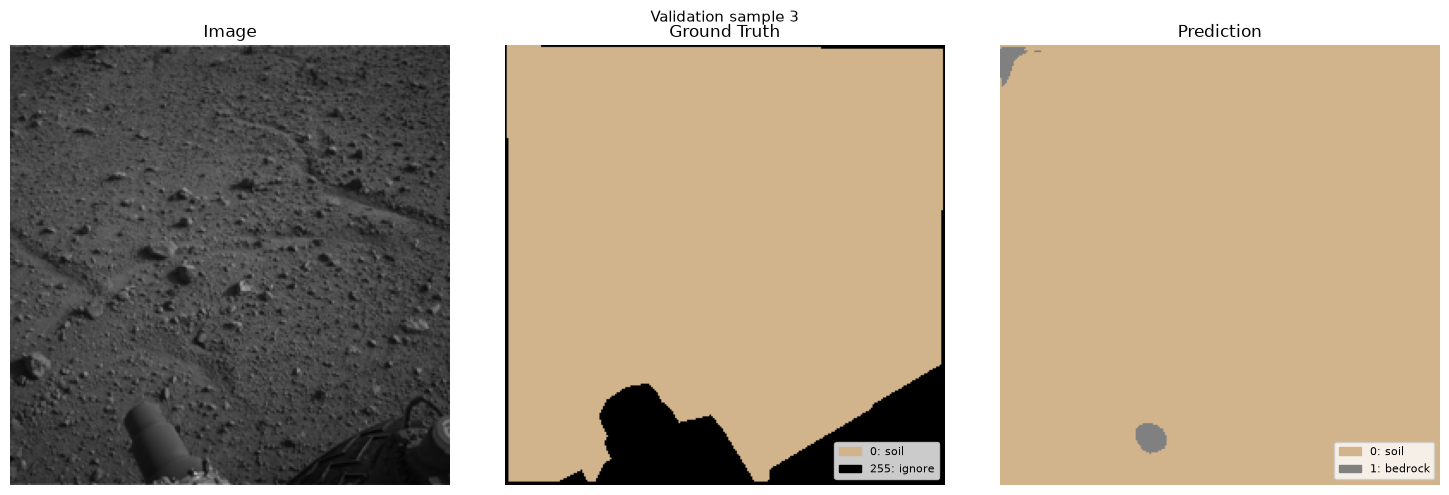

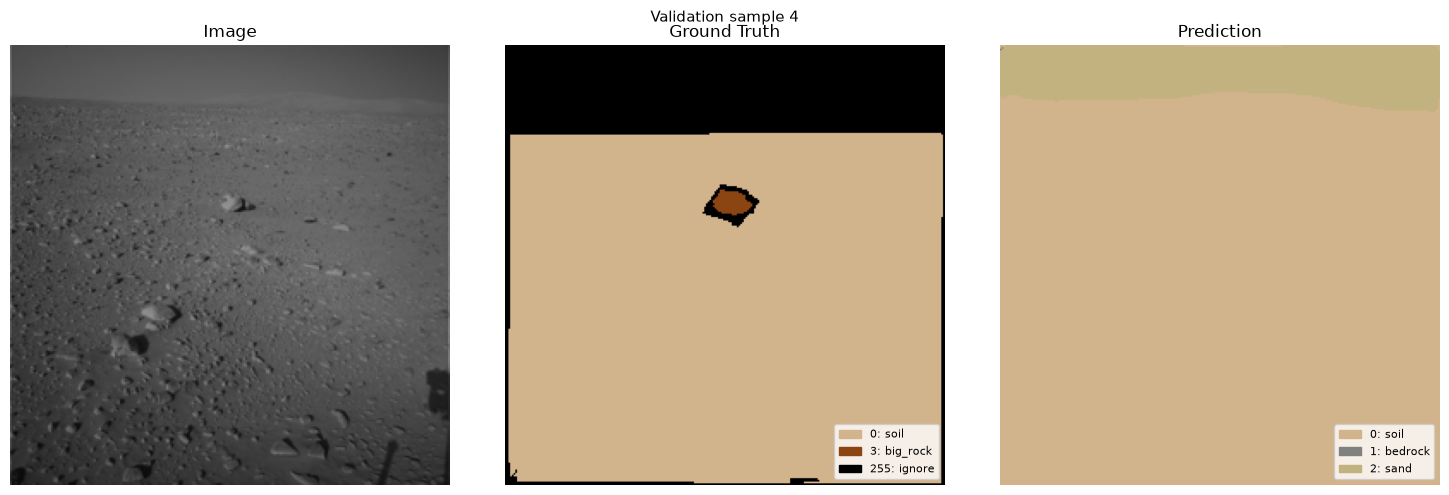

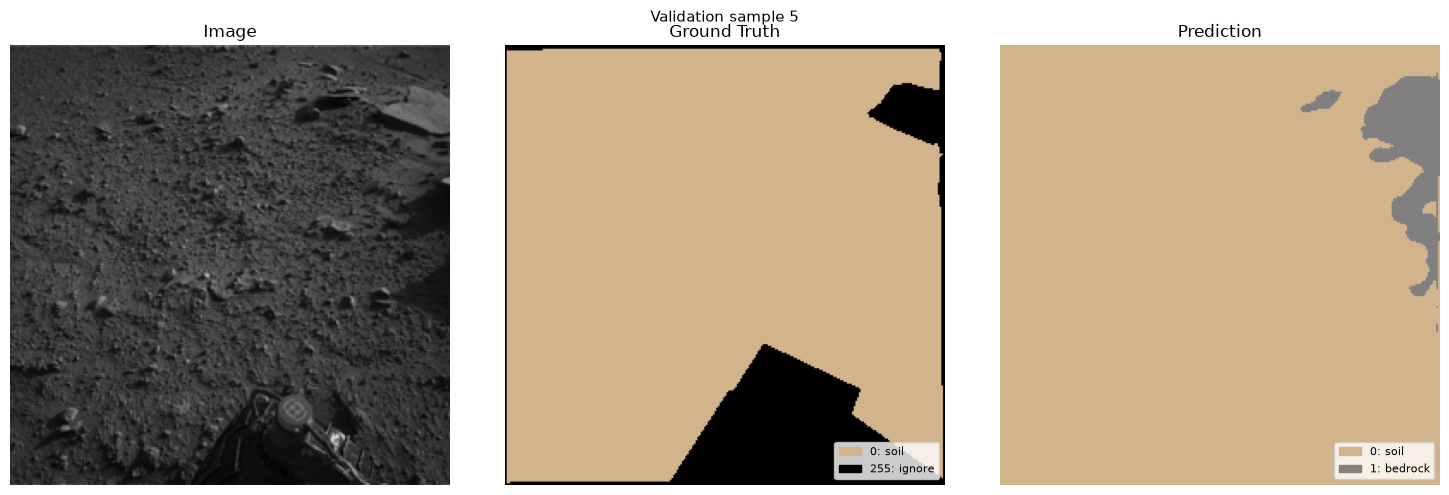

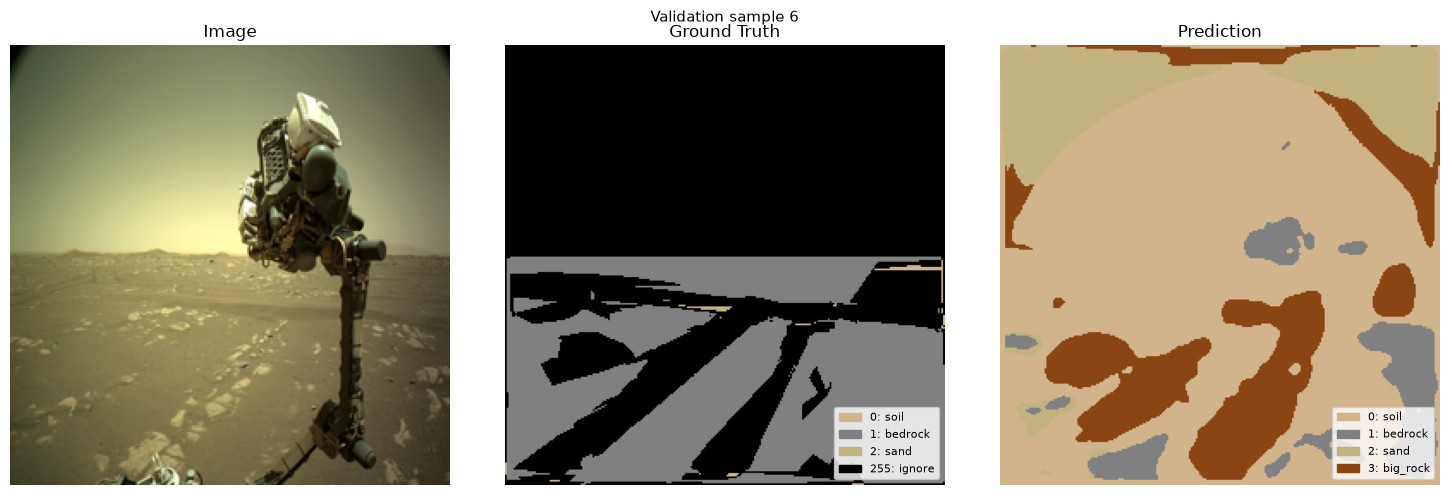

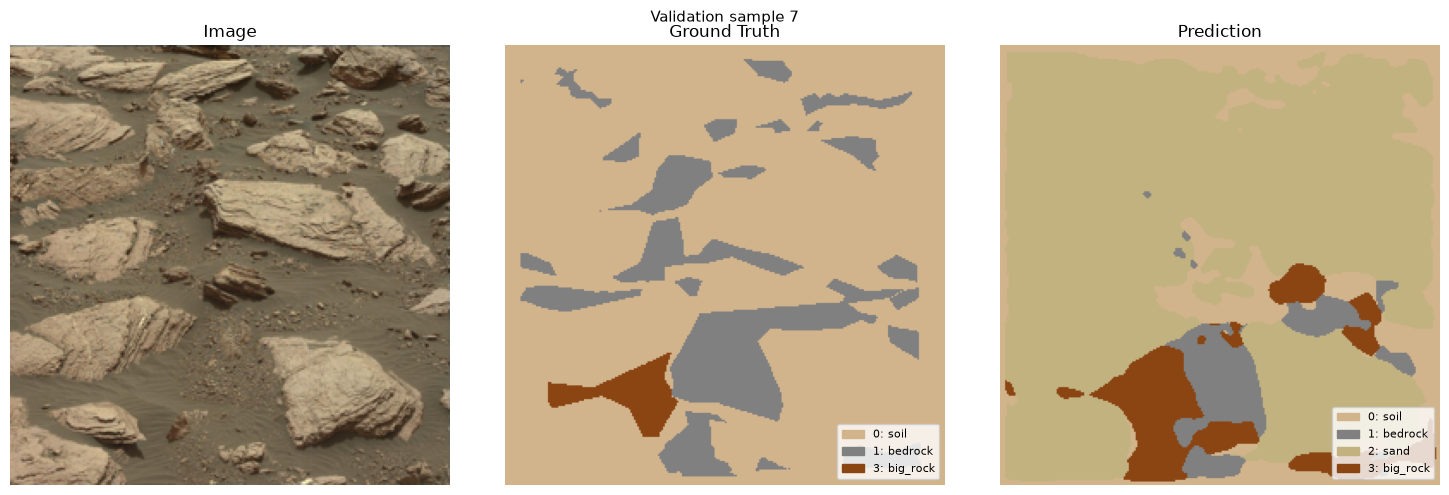

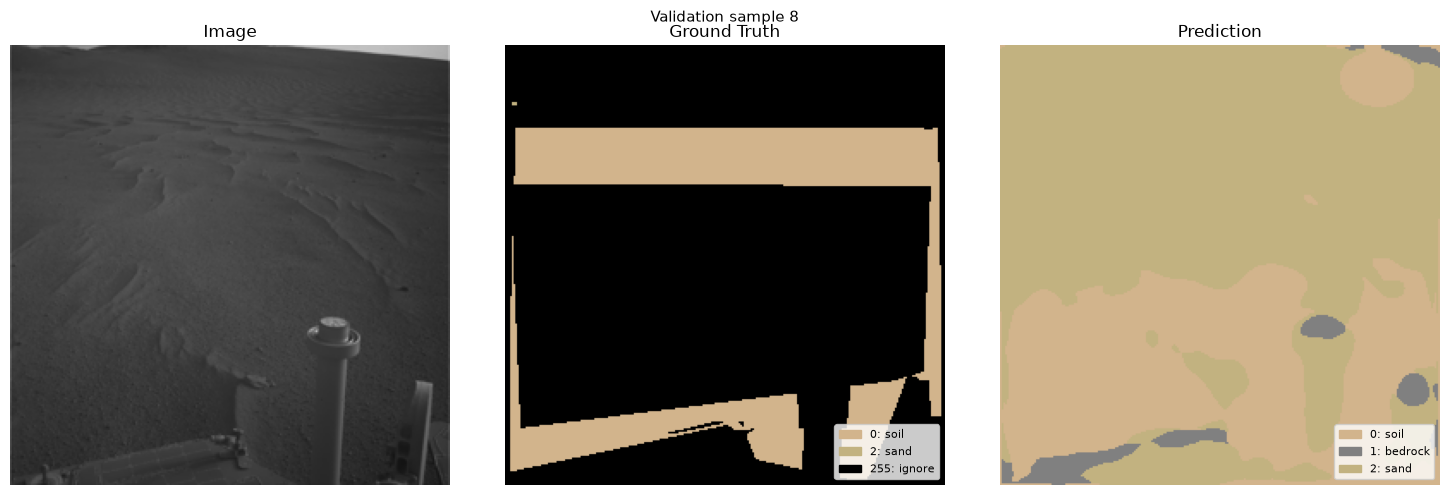

Displayed 8 validation samples.


In [ ]:
analysis_dir = FIGURES_DIR / "04_evaluation_error_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

if RUN_FULL_EVAL:
    example_groups = [
        ("best", best_sample_ids),
        ("worst", worst_sample_ids),
    ]

    for group_name, sample_ids in example_groups:
        for rank, sample_id in enumerate(sample_ids, start=1):
            image_tensor, target_mask = val_dataset[sample_id]
            pred_mask = all_preds[sample_id]

            image_np = image_tensor.permute(1, 2, 0).numpy()
            target_np = target_mask.numpy()
            pred_np = pred_mask.numpy()
            sample_score = sample_mious[sample_id]

            fig, axes = plt.subplots(1, 3, figsize=(16, 5))
            show_image(image_np, title="Image", ax=axes[0])
            show_image_mask_overlay(image_np, target_np, title="Ground Truth Overlay", ax=axes[1])
            show_image_mask_overlay(image_np, pred_np, title="Prediction Overlay", ax=axes[2])
            plt.suptitle(f"{group_name.title()} sample {rank} (validation idx {sample_id + 1}, mIoU={sample_score:.4f})", fontsize=11)
            plt.tight_layout()

            overlay_path = analysis_dir / f"{group_name}_sample_{rank:02d}_idx_{sample_id + 1:04d}_miou_{sample_score:.4f}.png"
            fig.savefig(overlay_path, dpi=150, bbox_inches="tight")
            print(f"Saved {group_name} overlay to {overlay_path}")
            plt.show()
            plt.close(fig)
else:
    print("Run the full evaluation first to generate best/worst overlays.")



---

### Observations

| # | Failure type | Example samples | Likely cause |
|---|---|---|---|
| 1 | Sample 1: label under-coverage vs visible rocks | Sample 1 | GT marks almost everything as soil/sand while image contains many rock-like structures; weak/incomplete annotation inflates apparent model error |
| 2 | Sample 1: big_rock over-prediction | Sample 1 | Model creates large big_rock islands not supported by GT mask; big_rock precision is low under class imbalance and texture ambiguity |
| 3 | Sample 1: scattered bedrock speckles | Sample 1 | Small isolated bedrock patches suggest noisy logits and insufficient spatial regularization |
| 4 | Sample 2: strong domain shift (wheel/hardware scene) | Sample 2 | Training data appears terrain-centric; rover hardware textures trigger large false positive big_rock regions |
| 5 | Sample 2: sparse GT polygon vs dense prediction | Sample 2 | GT has a small sand wedge only, while model predicts many classes; annotation sparsity/coverage mismatch dominates perceived failure |
| 6 | Sample 2: fragmented class islands | Sample 2 | Pepper-like bedrock/rock blobs indicate unstable boundaries and over-segmentation in cluttered scenes |
| 7 | Sample 3: ignore-region leakage | Sample 3 | GT includes large ignore zones, but prediction assigns valid classes inside/near those regions; ignore handling is weak at boundaries |
| 8 | Sample 3: false bedrock blob in mostly-soil frame | Sample 3 | Isolated bedrock prediction appears without clear visual support; likely confidence calibration issue |
| 9 | Sample 4: missed tiny big_rock target (false negative) | Sample 4 | Small labeled rock is not recovered; downsampling and low effective resolution hurt small-object recall |
| 10 | Sample 4: horizon band class confusion | Sample 4 | Predicted upper band as sand while GT top is ignore/background; model overextends terrain classes into non-target area |
| 11 | Sample 4: overly smooth segmentation field | Sample 4 | Prediction collapses to broad horizontal regions rather than object-aligned boundaries |
| 12 | Sample 5: right-edge bedrock hallucination | Sample 5 | Large bedrock region appears on right border without GT support; edge artifacts and contrast bias likely contributors |
| 13 | Sample 5: ignore-dominant GT mismatch | Sample 5 | GT has substantial ignore masks, but model fills most of frame with valid classes, reducing alignment with labels |
| 14 | Sample 6: severe class disagreement in mixed rover/terrain scene | Sample 6 | GT marks large bedrock+ignore structures while prediction redistributes area across soil/sand/big_rock; possible annotation semantics mismatch |
| 15 | Sample 6: large contiguous big_rock false positives | Sample 6 | Bottom-half prediction contains oversized big_rock regions not reflected in GT, indicating low big_rock precision |
| 16 | Sample 6: bedrock under-detection | Sample 6 | GT bedrock occupies wide regions, but prediction yields only small bedrock patches |
| 17 | Sample 7: bedrock under-segmentation on slab field | Sample 7 | Many slab-like bedrock GT regions are reassigned to sand/soil, lowering bedrock recall |
| 18 | Sample 7: big_rock over-expansion | Sample 7 | Predicted big_rock spreads beyond labeled area and merges with neighboring regions |
| 19 | Sample 7: boundary bleeding between classes | Sample 7 | Adjacent classes merge with soft, shifted borders instead of matching sharp GT transitions |
| 20 | Sample 8: ignore-band mismatch and over-classification | Sample 8 | GT is largely ignore with narrow labeled bands, but prediction covers frame with soil/sand/bedrock labels |
| 21 | Sample 8: low-light texture confusion | Sample 8 | Dark dune textures are mapped to mixed classes with little structural evidence, suggesting weak photometric robustness |
| 22 | Cross-sample: border/corner artifacts | Samples 1, 2, 5, 8 | Frequent false regions near edges imply padding/resize artifacts and insufficient border-aware augmentation |
| 23 | Cross-sample: ignore-boundary instability | Samples 3, 4, 5, 6, 8 | Hard transitions around ignore masks are not preserved; loss does not strongly constrain near-ignore uncertainty |
| 24 | Cross-sample: small-object recall deficit | Samples 4, 7 | Small/compact rocks are often missed or absorbed into soil/sand due to scale and feature resolution limits |
| 25 | Cross-sample: class imbalance effects on big_rock | Samples 1, 2, 6, 7 | Big_rock shows both false positives and misses, consistent with unstable decision boundary for minority class |

### Ideas for Improvement

- [ ] Add stronger augmentation (flip, color jitter, contrast).
- [ ] Tune class weights using measured label frequencies from NAV masks.
- [ ] Train longer and use LR scheduling (e.g., cosine/one-cycle).
- [ ] Try larger input size for small rock recall if VRAM allows.
- [ ] Add overlay-only audits focused on the hardest IoU class.